11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch: 0
Epoch: 1000
Epoch: 2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


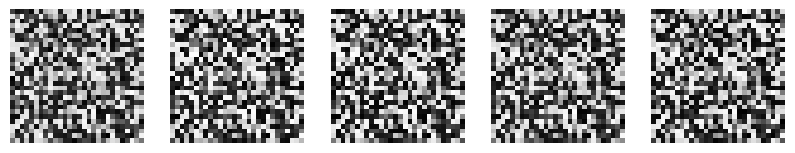

In [1]:
# ============================================================
# EXP 10 - GAN for Handwritten Digit Generation
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# 1. Load Dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1,1]
X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 28, 28, 1)

# 2. Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(256, activation='relu'),
        layers.Dense(784, activation='tanh'),
        layers.Reshape((28,28,1))
    ])
    return model

# 3. Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# 4. GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Training
epochs = 3000
batch_size = 64

for epoch in range(epochs):
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    noise = np.random.normal(0,1,(batch_size,100))
    gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 1000 == 0:
        print("Epoch:", epoch)

# 6. Generate Images
noise = np.random.normal(0,1,(5,100))
gen_imgs = generator.predict(noise)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# ============================================================
# END
# ============================================================